Descripción del modelo: ConvLSTM con 4 bloques, cada uno con BatchNormalization y activación. Con suma residual, kernel regularization y Dropout 0.4. Función para el sobre ajuste Decay Cosenoidal con learning rate. Se uso Early Stopping y se configuró validación del 20% de los datos. Se aumenta el número de datos a dos meses.

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Add, Activation, BatchNormalization, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

# =====================================================
# CONFIGURACIÓN DE RUTAS
# =====================================================

d_original = '/home/jhon/bandas/banda13/ene_oct_10m'
d_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'

if not os.path.exists(d_reducida):
    os.makedirs(d_reducida)

# =====================================================
# FUNCIONES AUXILIARES
# =====================================================

def resize_npy_images(d_original, d_reducida, new_size=(480, 480)):
    print(f"Redimensionando imágenes en {d_original}...")

    if not os.path.exists(d_reducida):
        os.makedirs(d_reducida)

    processed_count = 0
    for filename in os.listdir(d_original):
        if filename.lower().endswith('.npy'):
            img_path = os.path.join(d_original, filename)
            img_array = np.load(img_path)
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            output_path = os.path.join(d_reducida, filename)
            np.save(output_path, img_resized)
            processed_count += 1

    print(f"Procesadas {processed_count} imágenes")
    return processed_count

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)

    for i in range(n):
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

# =====================================================
# PREPROCESAMIENTO DE DATOS
# =====================================================

print("=" * 50)
print("PREPROCESAMIENTO DE IMÁGENES")
print("=" * 50)

# Verificar y redimensionar imágenes si es necesario
print("Verificando si necesitas redimensionar imágenes...")
existing_files = len([f for f in os.listdir(d_reducida) if f.endswith('.npy')])
if existing_files == 0:
    processed_count = resize_npy_images(d_original, d_reducida, new_size=(480, 480))
    print(f"✅ Redimensionadas {processed_count} imágenes")
else:
    print(f"✅ Ya existen {existing_files} imágenes redimensionadas en {d_reducida}")

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])
print(f"\nCargando {len(file_list)} imágenes desde {d_reducida}...")

images = []
for i, filename in enumerate(file_list):
    img_path = os.path.join(d_reducida, filename)
    img_array = np.load(img_path)
    images.append(img_array)

    if (i + 1) % 100 == 0:
        print(f"  Cargadas {i + 1}/{len(file_list)} imágenes...")

print(f"✅ Carga completada: {len(images)} imágenes")

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

print(f"✅ Normalización global completada: min={global_min}, max={global_max}")

# Construir secuencias temporales
print("\nConstruyendo secuencias temporales...")
timesteps = 3

X_base = np.array(images)[..., np.newaxis]
y_base = X_base.copy()

N_seq = X_base.shape[0] - timesteps
X_seq = np.array([X_base[i:i+timesteps] for i in range(N_seq)])
y_seq = y_base[timesteps:]

print(f"✅ Secuencias creadas:")
print(f"   - Forma de X_seq: {X_seq.shape}")
print(f"   - Forma de y_seq: {y_seq.shape}")
print(f"   - Número de secuencias: {N_seq}")

# =====================================================
# MODELO SIMPLIFICADO - SIN FUNCIONES ANIDADAS
# =====================================================

print("\n" + "=" * 50)
print("CONSTRUYENDO MODELO SIMPLIFICADO")
print("=" * 50)

# Parámetros
H, W, C = X_seq.shape[2], X_seq.shape[3], X_seq.shape[4]
semilla = 42
tf.random.set_seed(semilla)

# =====================================================
# CONSTRUCCIÓN CAPA POR CAPA
# =====================================================

# Capa de entrada
inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

# =====================================================
# BLOQUE 1: Extracción multi-escala inicial
# =====================================================

# Rama 3x3 del Bloque 1
block1_conv3x3 = ConvLSTM2D(
    16, (3, 3), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block1_conv3x3'
)(inputs)
block1_conv3x3_bn = TimeDistributed(BatchNormalization())(block1_conv3x3)
block1_conv3x3_act = Activation('relu')(block1_conv3x3_bn)

# Rama 5x5 del Bloque 1
block1_conv5x5 = ConvLSTM2D(
    16, (5, 5), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block1_conv5x5'
)(inputs)
block1_conv5x5_bn = TimeDistributed(BatchNormalization())(block1_conv5x5)
block1_conv5x5_act = Activation('relu')(block1_conv5x5_bn)

# Fusión por SUMA
block1_merged = Add()([block1_conv3x3_act, block1_conv5x5_act])
block1_output = Activation('relu', name='block1_output')(block1_merged)
block1_dropout = Dropout(0.4)(block1_output)

# =====================================================
# BLOQUE 2: Con conexión residual
# =====================================================

# Guardar para conexión residual
residual_shortcut = block1_dropout

# Rama 3x3 del Bloque 2
block2_conv3x3 = ConvLSTM2D(
    16, (3, 3), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block2_conv3x3'
)(block1_dropout)
block2_conv3x3_bn = TimeDistributed(BatchNormalization())(block2_conv3x3)
block2_conv3x3_act = Activation('relu')(block2_conv3x3_bn)

# Rama 5x5 del Bloque 2
block2_conv5x5 = ConvLSTM2D(
    16, (5, 5), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block2_conv5x5'
)(block1_dropout)
block2_conv5x5_bn = TimeDistributed(BatchNormalization())(block2_conv5x5)
block2_conv5x5_act = Activation('relu')(block2_conv5x5_bn)

# Fusión por suma
block2_merged = Add()([block2_conv3x3_act, block2_conv5x5_act])

# Conexión RESIDUAL
block2_residual = Add()([block2_merged, residual_shortcut])
block2_activated = Activation('relu', name='block2_output')(block2_residual)
block2_dropout = Dropout(0.4)(block2_activated)

# =====================================================
# BLOQUE 3: Procesamiento profundo
# =====================================================

# Rama 3x3 del Bloque 3
block3_conv3x3 = ConvLSTM2D(
    32, (3, 3), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block3_conv3x3'
)(block2_dropout)
block3_conv3x3_bn = TimeDistributed(BatchNormalization())(block3_conv3x3)
block3_conv3x3_act = Activation('relu')(block3_conv3x3_bn)

# Rama 5x5 del Bloque 3
block3_conv5x5 = ConvLSTM2D(
    32, (5, 5), padding='same',
    return_sequences=True,
    kernel_regularizer=l2(1e-4),
    name='block3_conv5x5'
)(block2_dropout)
block3_conv5x5_bn = TimeDistributed(BatchNormalization())(block3_conv5x5)
block3_conv5x5_act = Activation('relu')(block3_conv5x5_bn)

# Fusión por suma
block3_merged = Add()([block3_conv3x3_act, block3_conv5x5_act])
block3_output = Activation('relu', name='block3_output')(block3_merged)
block3_dropout = Dropout(0.4)(block3_output)

# =====================================================
# CAPA FINAL
# =====================================================

# Última capa ConvLSTM
final_convLSTM = ConvLSTM2D(
    16, (3, 3), padding='same',
    return_sequences=False,
    kernel_regularizer=l2(1e-4),
    name='final_convLSTM'
)(block3_dropout)

# Capa de salida
outputs = Conv2D(
    1, (1, 1), padding='same',
    activation='linear',
    name='output'
)(final_convLSTM)

# =====================================================
# CREAR MODELO
# =====================================================

model16 = Model(inputs=inputs, outputs=outputs, name='ConvLSTM_16')

# Compilar modelo
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)

model16.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("✅ Modelo construido capa por capa:")
model16.summary()

# =====================================================
# CALLBACKS
# =====================================================

def cosine_decay_schedule(epoch, lr):
    epochs_total = 50
    min_lr = 1e-5

    if epoch < 10:
        return lr
    else:
        cosine_decay = 0.5 * (1 + np.cos(np.pi * (epoch - 10) / (epochs_total - 10)))
        new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
        return new_lr

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath="modelo16_best.h5", monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    LearningRateScheduler(cosine_decay_schedule, verbose=1)
]

# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("\n" + "=" * 50)
print("DIVISIÓN DE DATOS")
print("=" * 50)

porc_validacion = 0.2
split_index = int(len(X_seq) * (1 - porc_validacion))

X_train, X_val = X_seq[:split_index], X_seq[split_index:]
y_train, y_val = y_seq[:split_index], y_seq[split_index:]

print(f"✅ Datos divididos:")
print(f"   - Entrenamiento: {len(X_train)} muestras")
print(f"   - Validación: {len(X_val)} muestras")

# =====================================================
# ENTRENAMIENTO
# =====================================================

print("\n" + "=" * 50)
print("INICIANDO ENTRENAMIENTO")
print("=" * 50)

history16 = model16.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=1,
    callbacks=callbacks,
    verbose=1
)

print("✅ ¡Entrenamiento completado!")

# =====================================================
# RESULTADOS
# =====================================================

print("\n" + "=" * 50)
print("RESULTADOS DEL ENTRENAMIENTO")
print("=" * 50)

final_train_loss = history16.history['loss'][-1]
final_val_loss = history16.history['val_loss'][-1]
best_epoch = np.argmin(history16.history['val_loss']) + 1

print(f"📊 Resultados finales:")
print(f"   - Pérdida final entrenamiento: {final_train_loss:.4f}")
print(f"   - Pérdida final validación: {final_val_loss:.4f}")
print(f"   - Mejor época: {best_epoch}")

print("\n🎯 ¡Proceso completado! Modelo guardado: modelo16_best.h5")

2025-10-30 06:35:31.627012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 06:35:31.726245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-30 06:35:31.773977: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-30 06:35:31.787861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-30 06:35:31.859010: I tensorflow/core/platform/cpu_feature_guar

PREPROCESAMIENTO DE IMÁGENES
Verificando si necesitas redimensionar imágenes...
✅ Ya existen 7266 imágenes redimensionadas en /home/jhon/bandas/banda13/ene_oct_10m_reducida

Cargando 7266 imágenes desde /home/jhon/bandas/banda13/ene_oct_10m_reducida...
  Cargadas 100/7266 imágenes...
  Cargadas 200/7266 imágenes...
  Cargadas 300/7266 imágenes...
  Cargadas 400/7266 imágenes...
  Cargadas 500/7266 imágenes...
  Cargadas 600/7266 imágenes...
  Cargadas 700/7266 imágenes...
  Cargadas 800/7266 imágenes...
  Cargadas 900/7266 imágenes...
  Cargadas 1000/7266 imágenes...
  Cargadas 1100/7266 imágenes...
  Cargadas 1200/7266 imágenes...
  Cargadas 1300/7266 imágenes...
  Cargadas 1400/7266 imágenes...
  Cargadas 1500/7266 imágenes...
  Cargadas 1600/7266 imágenes...
  Cargadas 1700/7266 imágenes...
  Cargadas 1800/7266 imágenes...
  Cargadas 1900/7266 imágenes...
  Cargadas 2000/7266 imágenes...
  Cargadas 2100/7266 imágenes...
  Cargadas 2200/7266 imágenes...
  Cargadas 2300/7266 imágenes.

2025-10-30 06:36:05.640544: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46779 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


✅ Modelo construido capa por capa:


Model: "ConvLSTM_16"

...


DIVISIÓN DE DATOS
✅ Datos divididos:
   - Entrenamiento: 5810 muestras
   - Validación: 1453 muestras

INICIANDO ENTRENAMIENTO

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/50


I0000 00:00:1761824192.923566    3991 service.cc:146] XLA service 0x25defc780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761824192.923592    3991 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-10-30 06:36:33.186893: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-30 06:36:34.067580: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
I0000 00:00:1761824204.349144    3991 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0260 - mean_absolute_percentage_error: 28.8736 - root_mean_squared_error: 0.1205
Epoch 1: val_loss improved from None to 0.01630, saving model to modelo16_best.h5


5810/5810 ━━━━━━━━━━━━━━━━━━━━ 1173s 199ms/step - loss: 0.0162 - mean_absolute_percentage_error: 22.9280 - root_mean_squared_error: 0.0959 - val_loss: 0.0163 - val_mean_absolute_percentage_error: 42.7176 - val_root_mean_squared_error: 0.1155 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0084 - mean_absolute_percentage_error: 18.3940 - root_mean_squared_error: 0.0783
Epoch 2: val_loss improved from 0.01630 to 0.01422, saving model to modelo16_best.h5


5810/5810 ━━━━━━━━━━━━━━━━━━━━ 1148s 198ms/step - loss: 0.0078 - mean_absolute_percentage_error: 18.2889 - root_mean_squared_error: 0.0779 - val_loss: 0.0142 - val_mean_absolute_percentage_error: 41.4474 - val_root_mean_squared_error: 0.1151 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0066 - mean_absolute_percentage_error: 17.5121 - root_mean_squared_error: 0.0760
Epoch 3: val_loss did not improve from 0.01422
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 1147s 197ms/step - loss: 0.0065 - mean_absolute_percentage_error: 17.5856 - root_mean_squared_error: 0.0760 - val_loss: 0.0168 - val_mean_absolute_percentage_error: 41.7844 - val_root_mean_squared_error: 0.1275 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0061 - mean_absolute_percentage_error: 1

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0055, RMSE final: 0.0728, MAPE final: 16.2132
Validación    - Loss final: 0.0341, RMSE final: 0.1842, MAPE final: 44.4752


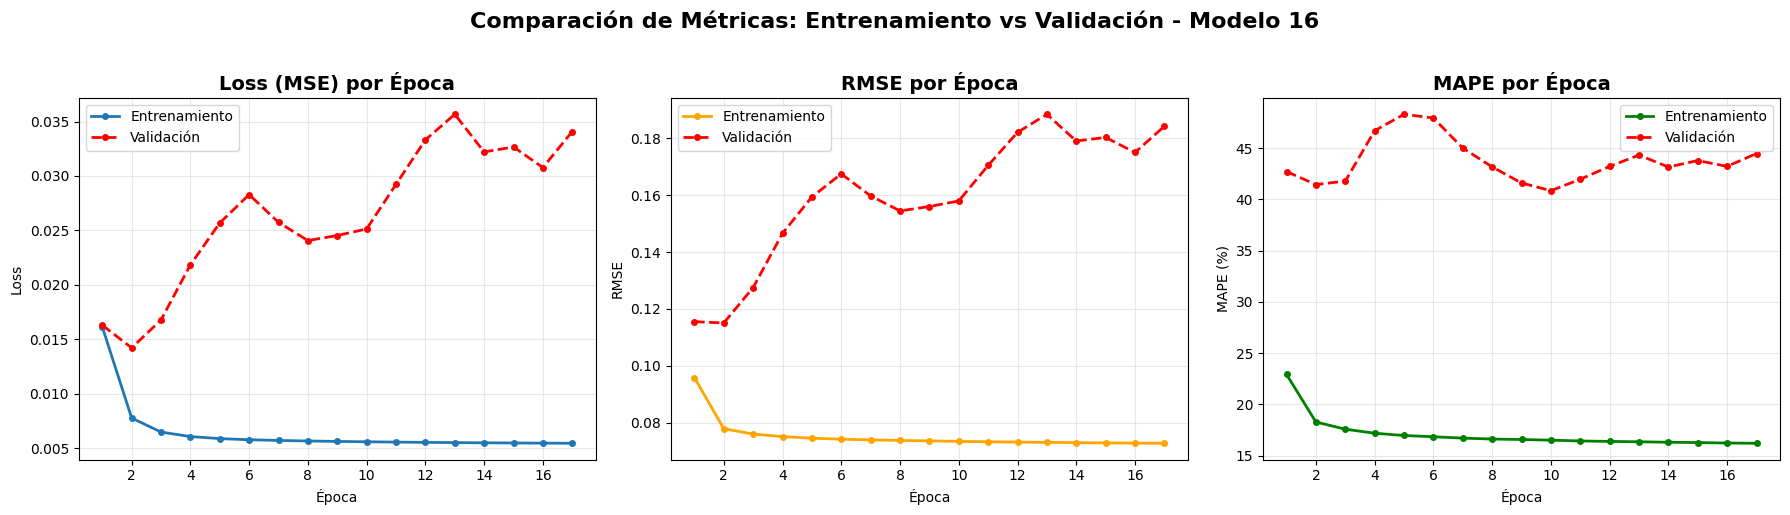

In [2]:

# Extraer métricas del historial (entrenamiento y validación)
loss = history16.history['loss']
val_loss = history16.history['val_loss']

rmse = history16.history['root_mean_squared_error']
val_rmse = history16.history['val_root_mean_squared_error']

mape = history16.history['mean_absolute_percentage_error']
val_mape = history16.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 16',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

182/182 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step


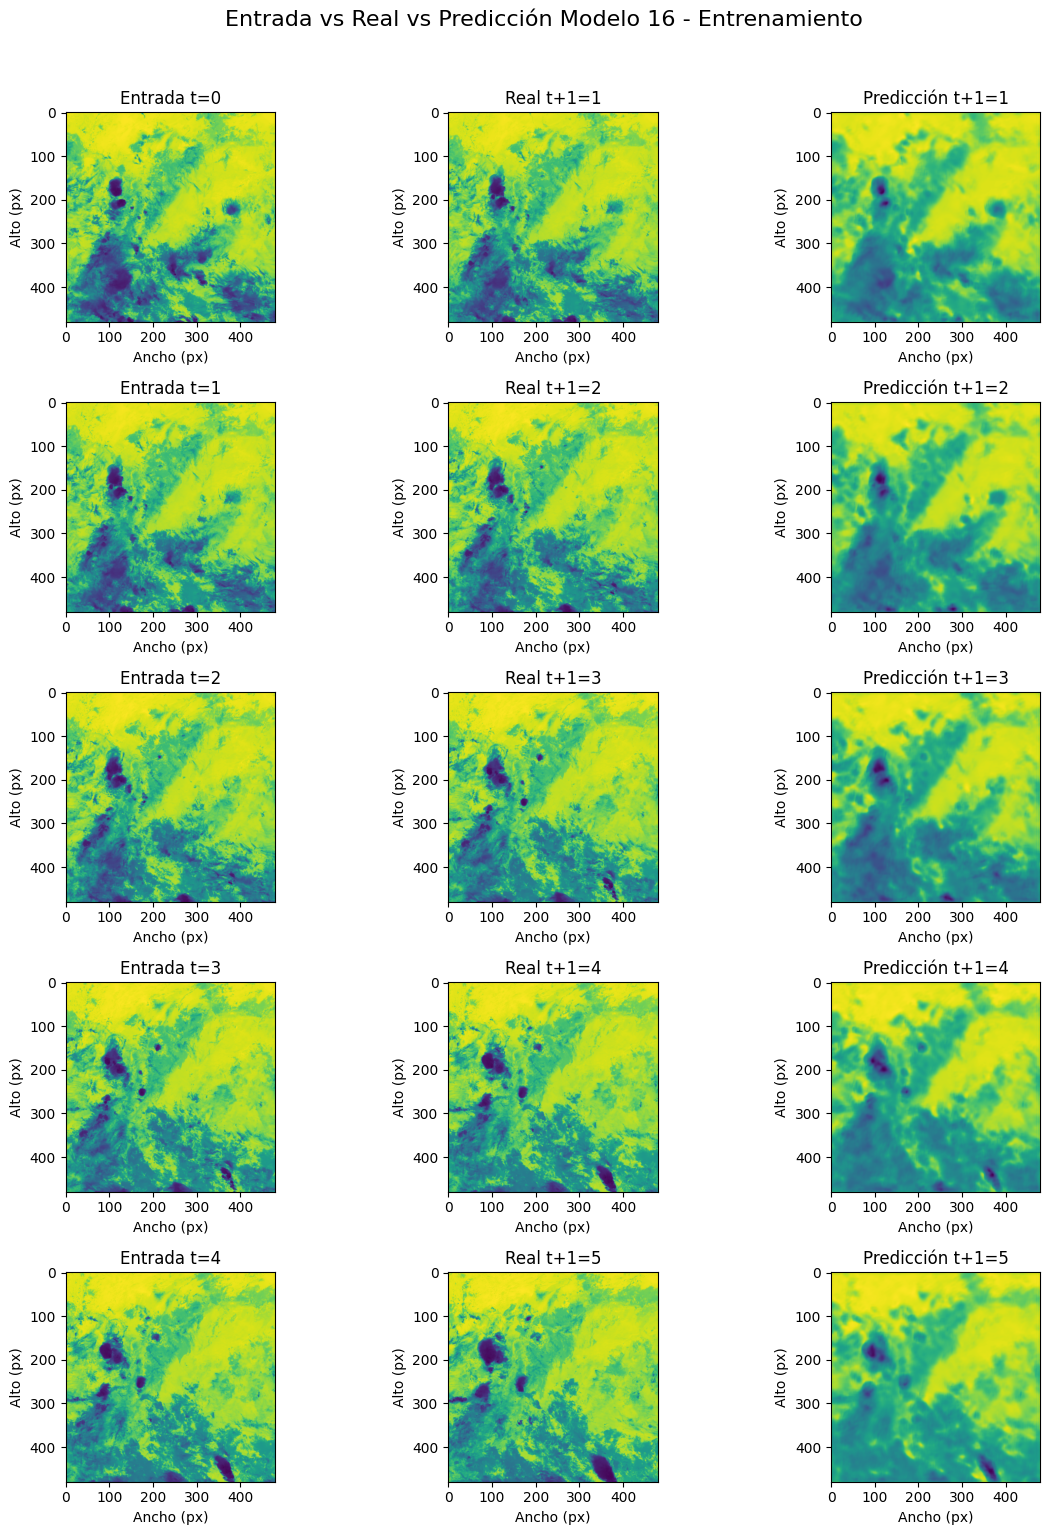

In [4]:
y_pred16_train = model16.predict(X_train)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_train[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_train,                   # Valores reales
    y_pred16_train,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 16 - Entrenamiento",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
    )

46/46 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step


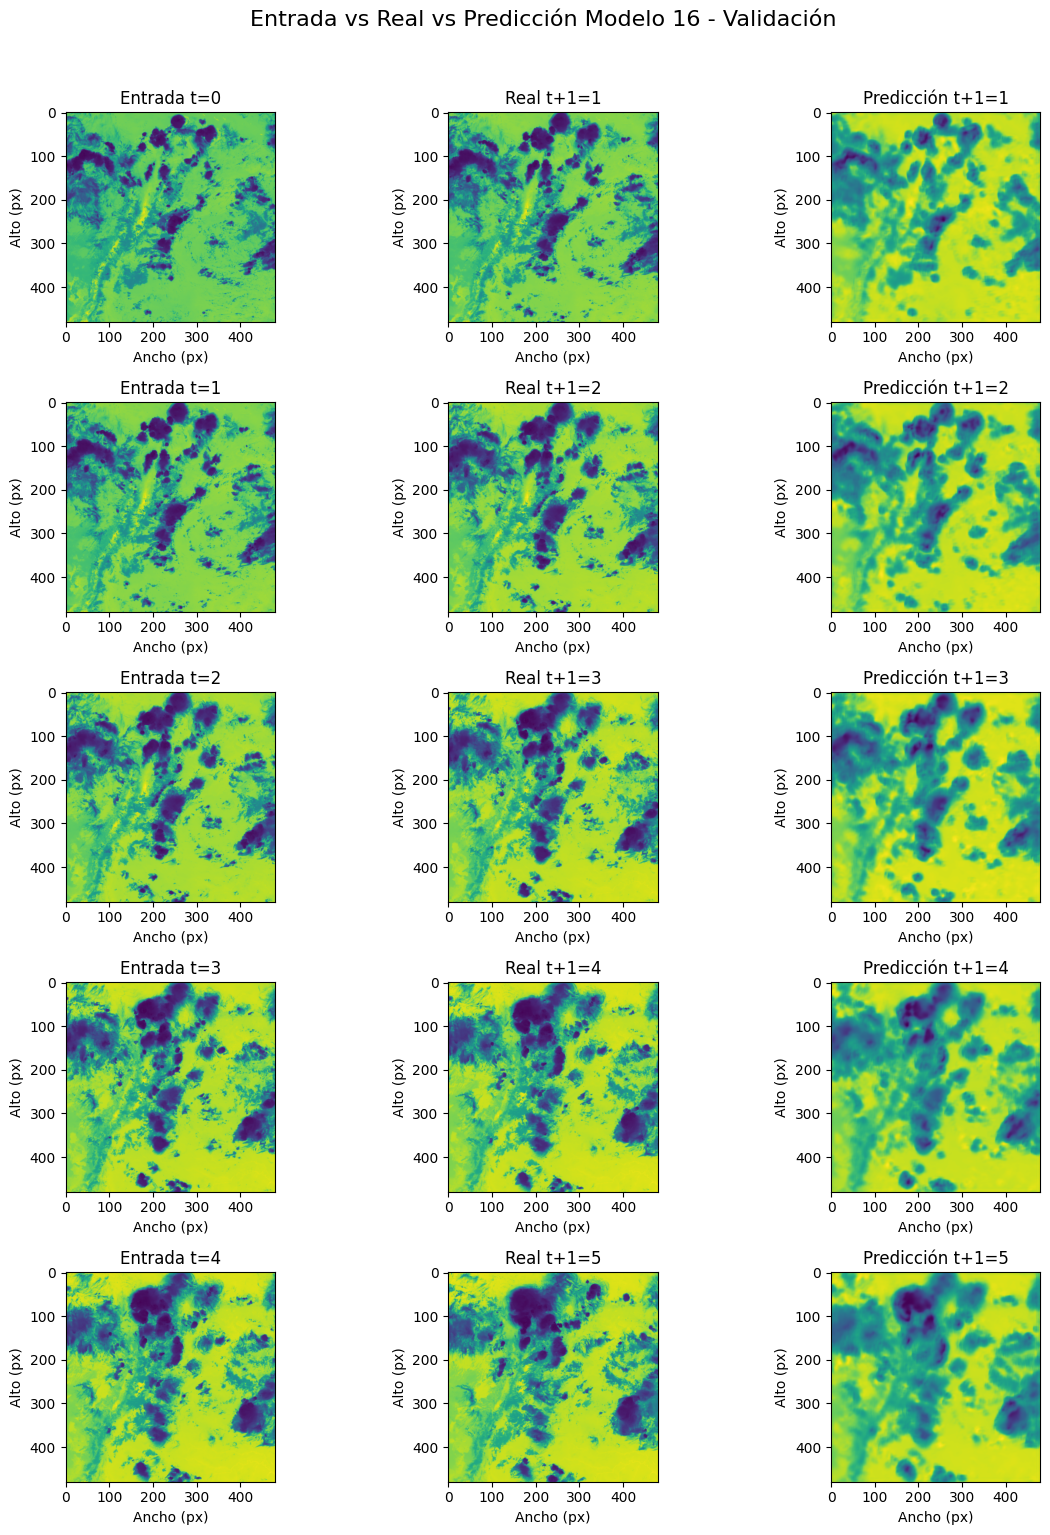

In [5]:
y_pred16_val = model16.predict(X_val)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_val[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_val,                   # Valores reales
    y_pred16_val,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 16 - Validación",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
    )

Datos de prueba:

In [6]:
# Directorio original y reducido para validación
d_mar_2s = '/home/jhon/bandas/banda13/nov_dic_2m'
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes
resize_npy_images(d_mar_2s, d_mar_2s_red, new_size=(480, 480))

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]

# Parámetro de secuencia temporal (debe ser el mismo que en entrenamiento)
timesteps = 3

# Construir secuencias para validación: X_seq_val (N, timesteps, H, W, C), y_seq_test (N, H, W, C)
X_base_test = np.array(images_test)[..., np.newaxis]  # (num_imgs_test, H, W, C)
y_base_test = X_base_test.copy()  # y_base_test igual a X_base_test

N_seq_test = X_base_test.shape[0] - timesteps
X_seq_test = np.array([X_base_test[i:i+timesteps] for i in range(N_seq_test)])  # (N_seq_test, timesteps, H, W, C)
y_seq_test= y_base_test[timesteps:]  # (N_seq_test, H, W, C)

print(f"Forma de X_seq_test: {X_seq_test.shape}")  # (N_seq_test, timesteps, H, W, C)
print(f"Forma de y_seq_test: {y_seq_test.shape}")  # (N_seq_test, H, W, C)

Redimensionando imágenes en /home/jhon/bandas/banda13/nov_dic_2m...
Procesadas 1447 imágenes
Procesando 1447 imágenes para validación
Forma de X_seq_test: (1444, 3, 480, 480, 1)
Forma de y_seq_test: (1444, 480, 480, 1)


In [7]:
# Ahora puedes evaluar el modelo
loss, rmse, mape = model16.evaluate(X_seq_test, y_seq_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0137 - mean_absolute_percentage_error: 35.3508 - root_mean_squared_error: 0.1129
Pérdida (MSE): 0.0137
RMSE: 0.1129
MAPE: 35.3508


46/46 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step


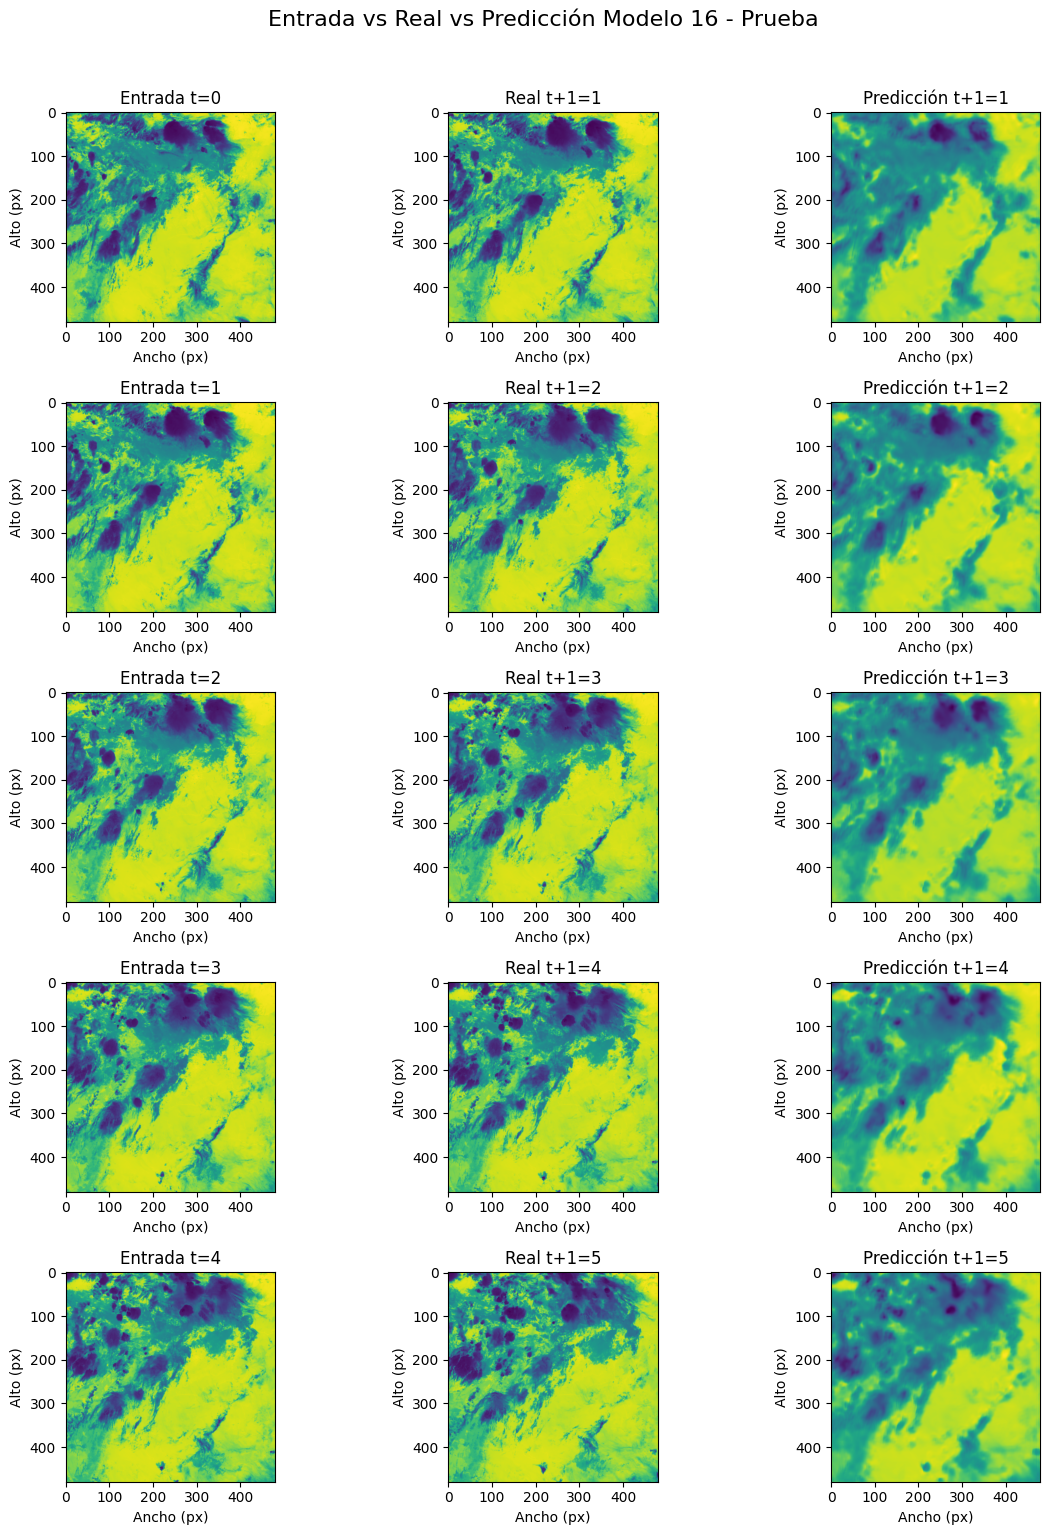

In [8]:
y_pred16_test = model16.predict(X_seq_test)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_seq_test[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_seq_test,                   # Valores reales
    y_pred16_test,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 16 - Prueba",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
)